<a href="https://colab.research.google.com/github/MateAlv/BioInformatica-Avanzada/blob/main/5_MayorVolumenCategories.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd


from google.colab import drive
drive.mount("/content/drive")

DATA_PATH = "/content/drive/MyDrive/CienciaDeDatos/TP1/data/"

df_categories = pd.read_csv(DATA_PATH + "categories.csv")
df_products = pd.read_csv(DATA_PATH + "products.csv")


Mounted at /content/drive


In [3]:
def normalize_category(s: pd.Series):
    s = s.astype("string").str.strip().str.lower()
    s = s.replace({"nan": None, "na": None, "undefined": None, "none": None, "": None})
    s = s.dropna()
    return s.str.title()

def normalize_columns(df: pd.DataFrame, columns: list[str]):
    for col in columns:
        df[f"{col}_clean"] = normalize_category(df[col])
    return df

# Asumiendo cm como medición base
CM3_TO_M3  = 1000000

def calculate_volume(dimensions):
    try:
        parts = str(dimensions).lower().split('x')
        dims = []
        for p in parts:
            dims.append(float(p))
        if len(dims) == 3:
            vol_cm3 = (float(parts[0]) * float(parts[1]) * float(parts[2]))
            return vol_cm3 / CM3_TO_M3
        else:
            return None
    except Exception:
        return None

df_categories_clean = normalize_columns(df_categories, ['category_name', 'parent_category'])
df_categories_clean = df_categories_clean[['category_id', 'category_name_clean', 'parent_category_clean']]

df_products['Volume'] = df_products['dimensions'].apply(calculate_volume)

df_products_clean = df_products[['product_id', 'Volume']]

df_products_categories = df_products.merge(
    df_categories_clean,
    on='category_id',
    how='inner'
)

df_volume_per_category = (
    df_products_categories
        .groupby('parent_category_clean', as_index=False)['Volume']
        .mean()
        .sort_values(by='Volume', ascending=False)
)

df_volume_per_category

,parent_category_clean,Volume
3,Books,0.543738
8,Furniture,0.543353
18,Music & Movies,0.537714
17,Kitchen & Dining,0.537683
16,Jewelry,0.537149
19,Musical Instruments,0.536750
5,Collectibles,0.536641
24,Sports & Outdoors,0.536457
26,Tickets & Experiences,0.536254
6,Electronics,0.536168


# Análisis

A partir del campo dimensions en cm y formato BasexAlturaxAncho, se calculó el volumen de cada producto como el producto de las 3 mediciones  y luego se convirtió a metros cúbicos dividiendo por 1.000.000. Se normalizaron las categorías (parent_category_clean) y se promedió el volumen dentro de cada categoría padre. Se excluyeron filas sin dimensiones parseables para no sesgar los resultados.
Los resultados de los mayores 3 fueron:


- Books:		0.543738 m³
- Furniture		0.543353 m³
- Music & Movies	0.537714 m³

Todas las categorías tuvieron valores prácticamente iguales, que variaron de 0.529462 m³ a 0.543738 m³. Esto me dió el fuerte indicio de que los datos están aleatorizados y no representan las dimensiones reales de productos de estas categorías, ya que es obvio que “Food & Beverages” debería tener productos masivamente más grandes que  “Furniture”, y sin embargo el valor promedio de volumen es casi idéntico. No pude extraer data de mayor significancia ya que se evidencia que el dataset no contiene del todo datos reales, sino simulados con factores al azar.


## Visualizaciones

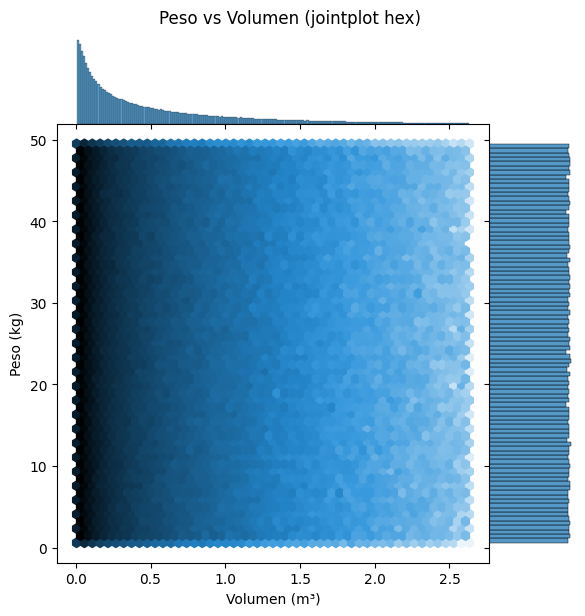

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cm3_a_m3 = 1_000_000
dims = (
    df_products['dimensions'].astype('string').str.strip().str.lower()
      .str.extract(r'(?P<L>\d+(?:\.\d+)?)x(?P<W>\d+(?:\.\d+)?)x(?P<H>\d+(?:\.\d+)?)')
      .astype(float)
)
df_products['Volume_m3'] = (dims['L'] * dims['W'] * dims['H']) / cm3_a_m3

df_vw = df_products[['Volume_m3','weight_kg']].copy()
df_vw['weight_kg'] = pd.to_numeric(df_vw['weight_kg'], errors='coerce')
df_vw = df_vw.dropna().query('Volume_m3 > 0 and weight_kg > 0')

qlo, qhi = df_vw['Volume_m3'].quantile([0.01, 0.99])
wlo, whi = df_vw['weight_kg'].quantile([0.01, 0.99])
df_vw = df_vw[df_vw['Volume_m3'].between(qlo, qhi) & df_vw['weight_kg'].between(wlo, whi)]

g = sns.jointplot(
    data=df_vw,
    x='Volume_m3', y='weight_kg',
    kind='hex', height=6, space=0, bins='log'
)
g.set_axis_labels('Volumen (m³)', 'Peso (kg)')
plt.suptitle('Peso vs Volumen (jointplot hex)', y=1.02)
plt.show()
